In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

In [2]:
from src.metrics import compute_psi, calculate_psi_dataframe, compute_holdout_metrics, generate_shap_waterfalls, model_monitoring_dashboard
import joblib
import os
import shap
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from sklearn.pipeline import Pipeline

E:\Users\Gautam\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Loading the datasets. Note that pipeline_train.csv and pipeline_test.csv are basically raw application_train.csv dataset split into 2
data_dir = Path("../data")
df_app_train = pd.read_csv(data_dir / "pipeline_train.csv")
df_app_test = pd.read_csv(data_dir / "pipeline_test.csv")
df_bureau = pd.read_csv(data_dir / "bureau.csv")

X_train = df_app_train.drop(columns=["TARGET"])
y_train = df_app_train["TARGET"]

X_test = df_app_test.drop(columns=["TARGET"])
y_test = df_app_test["TARGET"]

In [4]:
output_path = Path("../models/best_model.pkl")
clf = joblib.load(output_path)

In [5]:
pipeline = Pipeline([
    ('classifier', clf)
])
pipeline.set_params(classifier=clf)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('bureau_merger', ...), ('drop_high_missing', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value


### Finding the optimal threshold for maximising F1 score

In [6]:
# Predicted probabilities for the positive class

y_proba = pipeline.predict_proba(X_train)[:, 1]

# Test thresholds from 0.01 to 0.99
thresholds = np.arange(0.01, 1.00, 0.01)

f1_scores = [
    f1_score(y_train, (y_proba >= threshold).astype(int))
    for threshold in thresholds
]

# Find optimal threshold
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Optimal F1 threshold: {best_threshold:.2f}")
print(f"Best F1 score: {best_f1:.4f}")

Optimal F1 threshold: 0.68
Best F1 score: 0.3607


In [7]:
# 2. Fit pipeline on full training set
y_proba = pipeline.predict_proba(X_test)[:, 1]

# 3. Holdout Evaluation Metrics
auroc = roc_auc_score(y_test, y_proba)
metrics_df = compute_holdout_metrics(y_test, y_proba, auroc)
print(metrics_df)

       Metric   Value             Interpretation
0  Mean AUROC  0.7685   Model discriminates well
1        Gini  0.5370                       Good
2          KS  0.4004            Good separation
3       AUPRC  0.2571    Above baseline (0.0807)
4          F1  0.3216  Optimal threshold: 0.6796


E:\Users\Gautam\AppData\Local\Programs\Python\Python313\Lib\site-packages\shap\explainers\_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


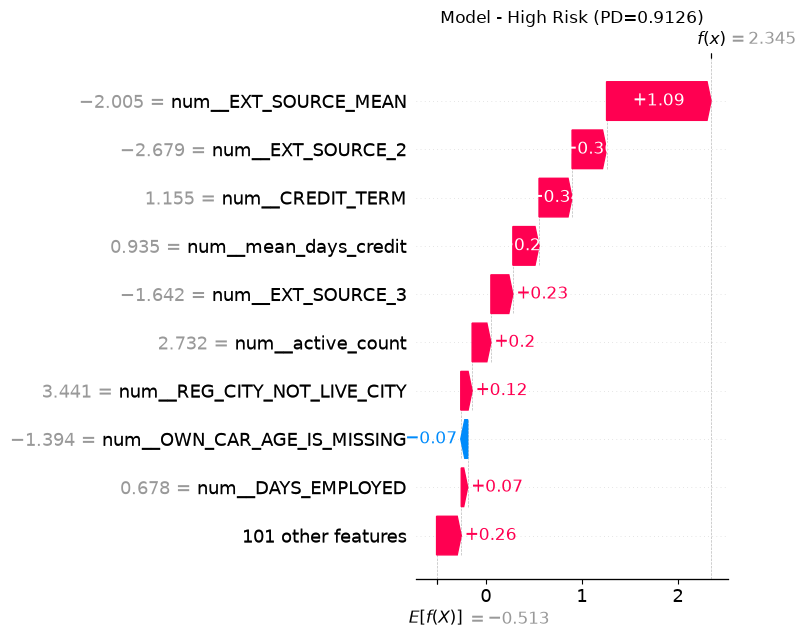

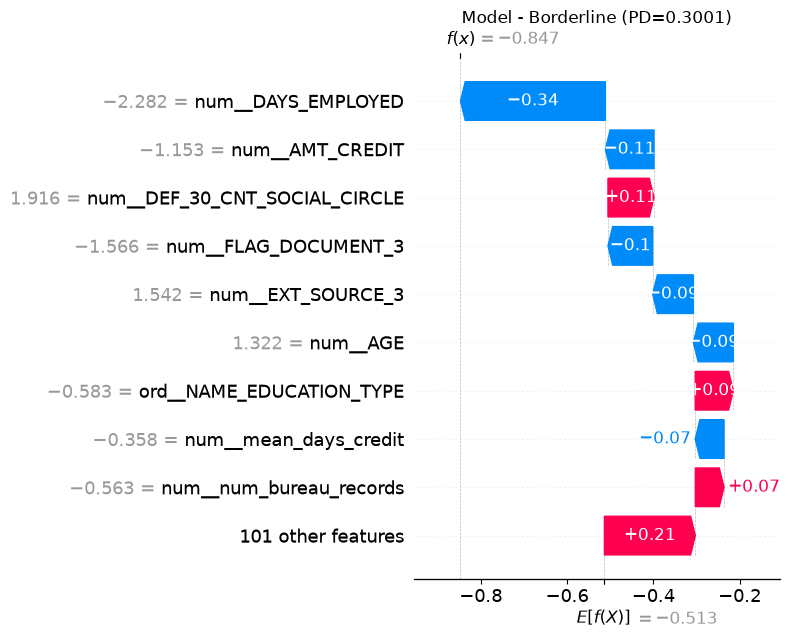

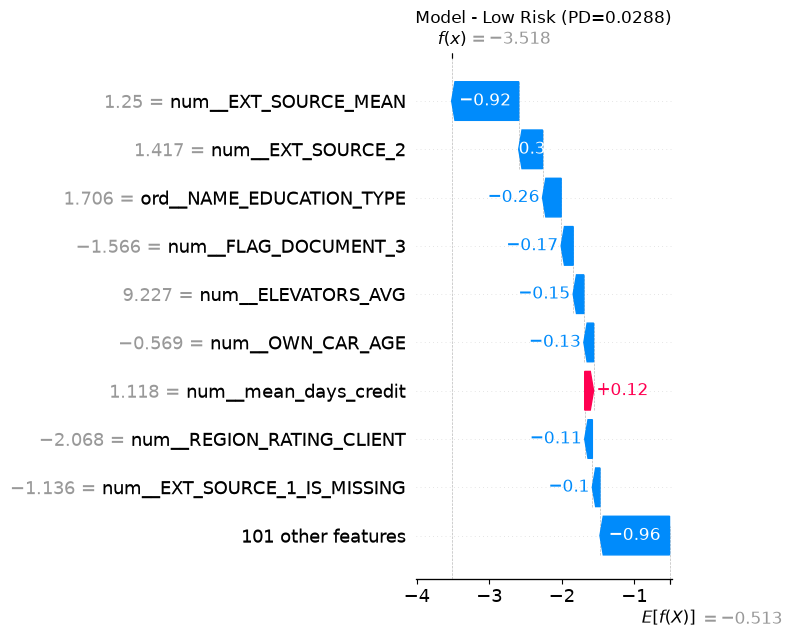

In [8]:
generate_shap_waterfalls(
    full_pipeline=pipeline.steps[-1][1], 
    X_train_raw=X_train, 
    X_test_raw=X_test,
    model_name="Model",
    n_samples=1000
)

Sample Adverse Action Notice for a high-risk applicant where the model predicted this person has a ~91% probability of defaulting:
> Our decision was made using an automated credit evaluation model. The primary factors contributing to this determination, ordered by their impact on the decision, are:
- Low Aggregate External Credit Rating (`EXT_SOURCE_MEAN = -2.005`, SHAP Impact: +1.09)
Your combined average score across external consumer reporting bureaus fell significantly below our minimum required approval threshold.
- Loan Term / Repayment Structure (`CREDIT_TERM = 1.155`, SHAP Impact: +0.33)
The requested loan duration/repayment term length creates a elevated payment commitment relative to your risk profile.
- Recency / Maturity of Credit Bureau History (`mean_days_credit = 0.935`, SHAP Impact: +0.25)
The average age of your reported credit lines indicates a credit profile that is too recently established to meet baseline requirements.
- High Number of Active Open Accounts (`active_count = 2.732`, SHAP Impact: +0.20)
You currently hold an excessive number of open, active credit obligations relative to our maximum allowance for new credit extensions.


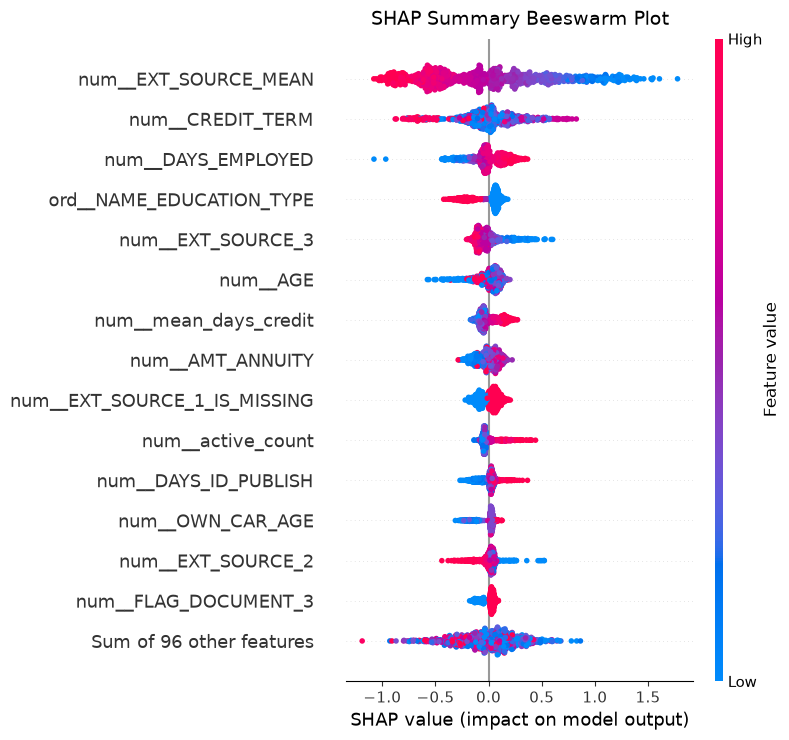

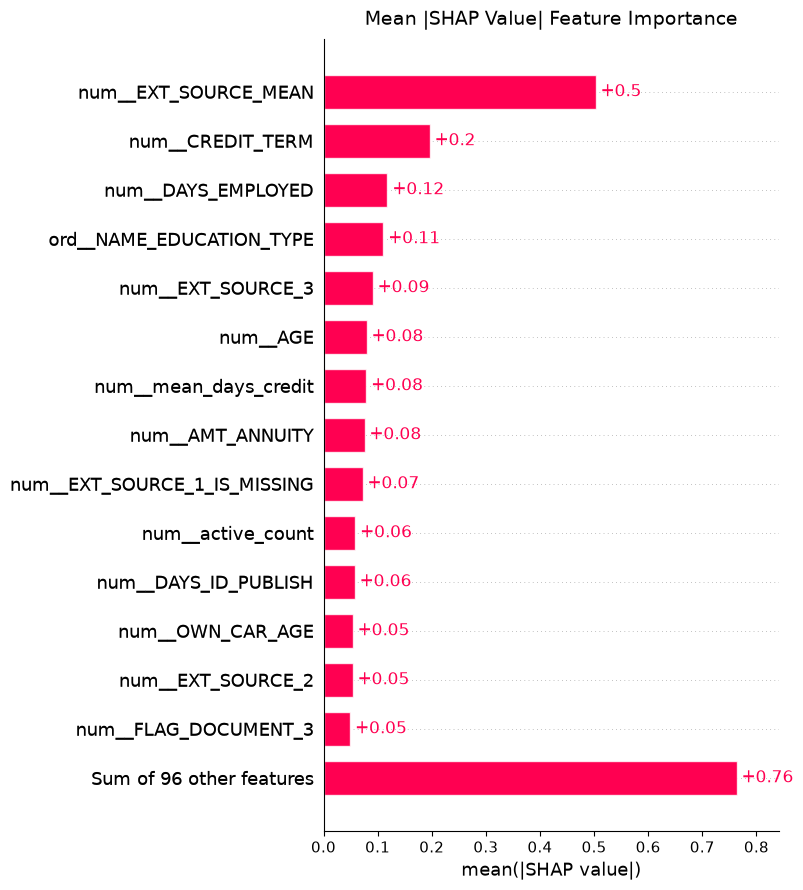

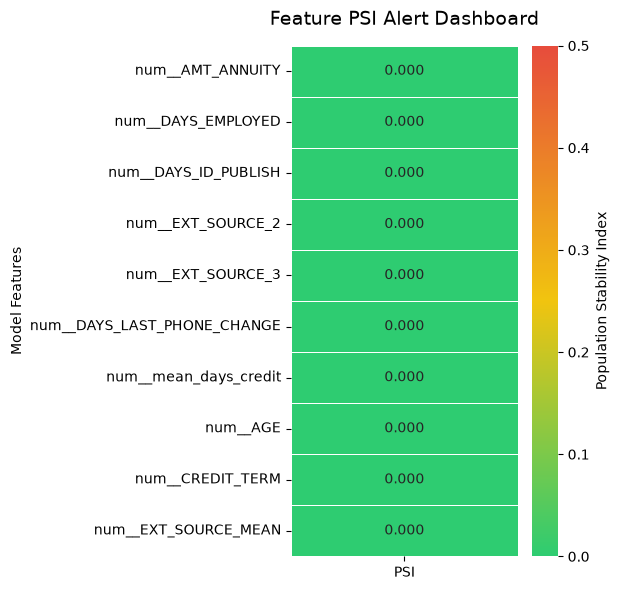

[LightGBM] [Info] Number of positive: 15888, number of negative: 180918
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.138196 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7548
[LightGBM] [Info] Number of data points in the train set: 196806, number of used features: 101
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432480
[LightGBM] [Info] Start training from score -2.432480
Fold 1 | AUROC: 0.7618 | AUC-PR: -0.2457 | Gini: 0.5237 | KS: 0.3942 | F1: 0.3083
[LightGBM] [Info] Number of positive: 15888, number of negative: 180918
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.082310 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7555
[LightGBM] [Info] Number 

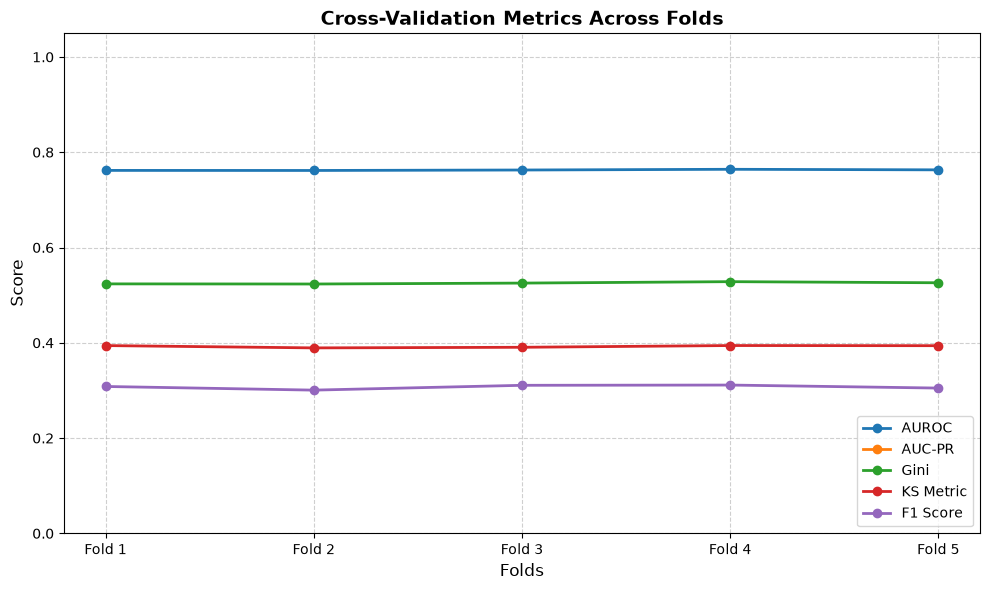

In [9]:
model_monitoring_dashboard(
    full_pipeline=pipeline.steps[-1][1],  # Guarantees the classifier is passed
    X_train_raw=X_train,               # Must be the preprocessed feature matrix
    y_train=y_train,
    X_test_raw=X_test,
    f1_threshold=best_threshold
)

## Model Validation Summary

### 1. Cross-Validation Performance

* **AUROC:** 0.7627 ± 0.0009, indicating strong and highly consistent class discrimination across folds.
* **Gini:** 0.5253 and **KS:** 0.3925, confirming solid rank-ordering performance.
* **F1:** 0.3072, reflecting weak precision/recall balance at the optimatl 0.68 threshold due to class imbalance.
* **AUC-PR:** Reported as 0.2476, the model's precision-recall performance is substantially better than the ~0.08 prevalence baseline (3x).

### 2. Feature Importance & Model Drivers

* **`EXT_SOURCE_MEAN`** is the strongest predictor, with lower external scores associated with higher predicted risk.
* **`CREDIT_TERM`** and **`DAYS_EMPLOYED`** are important secondary drivers.
* Higher **education levels** and stronger **external credit scores (`EXT_SOURCE_2`, `EXT_SOURCE_3`)** generally act as protective factors.

### 3. Feature Stability

* **PSI = 0.000** across the key monitored features, well below the standard concern threshold of **0.10**.
* This indicates **no material distribution drift** between the training and validation splits.
* Overall, the model demonstrates strong discrimination & stable feature distributions.
